In [1]:
# Semente fixa para reprodutibilidade
RANDOM_STATE = 42


# 01 — Análise Exploratória dos Dados (EDA)

**Grupo 50 • Tech Challenge — Fase 2**

## Objetivo

Carregar as bases `application_record.csv` e `credit_record.csv`, verificar estrutura e qualidade, construir uma visão inicial da variável-alvo e analisar distribuições, balanceamento, correlações, perfis repetidos e possíveis outliers.

> **Etapa do pipeline:** análise exploratória e diagnóstico da qualidade dos dados.  
> A variável `TARGET` é construída a partir do histórico de crédito, mas o histórico (`credit_record`) não é usado diretamente como variável preditora.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# O notebook funciona tanto no repositório local quanto no Google Colab.
ROOT_CANDIDATES = [
    Path(".."),                         # execução a partir de notebooks/
    Path("."),                          # execução a partir da raiz do projeto
    Path("/content"),                   # Google Colab com CSVs enviados
]

RAW = None
for root in ROOT_CANDIDATES:
    candidate = root / "data" / "raw"
    if (candidate / "application_record.csv").exists() and (candidate / "credit_record.csv").exists():
        RAW = candidate
        break

# No Colab, os CSVs podem estar diretamente em /content.
if RAW is None and Path("/content/application_record.csv").exists() and Path("/content/credit_record.csv").exists():
    RAW = Path("/content")

if RAW is None:
    raise FileNotFoundError(
        "Não foi possível localizar application_record.csv e credit_record.csv. "
        "No repositório, coloque-os em data/raw/. No Colab, envie os dois arquivos."
    )

ROOT = RAW.parent.parent if RAW.name == "raw" else RAW
FIG_DIR = ROOT / "docs" / "figuras_eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

APP_PATH = RAW / "application_record.csv"
CREDIT_PATH = RAW / "credit_record.csv"

print("Diretório dos dados:", RAW.resolve())
print("Diretório das figuras:", FIG_DIR.resolve())


Diretório dos dados: C:\projetos\Grupo_50_Tech-Challenge-Fase-2\data\raw
Diretório das figuras: C:\projetos\Grupo_50_Tech-Challenge-Fase-2\docs\figuras_eda


In [3]:
application = pd.read_csv(APP_PATH)
credit = pd.read_csv(CREDIT_PATH)

print(f"application_record: {application.shape[0]:,} linhas × {application.shape[1]} colunas")
print(f"credit_record:      {credit.shape[0]:,} linhas × {credit.shape[1]} colunas")

display(application.head())
display(credit.head())


application_record: 438,557 linhas × 18 colunas
credit_record:      1,048,575 linhas × 3 colunas


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


## 1. Estrutura e qualidade das bases

In [4]:
print("Tipos — application_record")
display(application.dtypes.to_frame("dtype"))

print("Tipos — credit_record")
display(credit.dtypes.to_frame("dtype"))

print("Valores ausentes — application_record")
missing_app = application.isna().sum().sort_values(ascending=False)
display(missing_app[missing_app > 0].to_frame("nulos"))

print("Valores ausentes — credit_record")
missing_credit = credit.isna().sum().sort_values(ascending=False)
display(missing_credit[missing_credit > 0].to_frame("nulos"))

print("Duplicidades exatas — application_record:", int(application.duplicated().sum()))
print("Duplicidades exatas — credit_record:", int(credit.duplicated().sum()))

print("IDs únicos — application_record:", application["ID"].nunique())
print("IDs únicos — credit_record:", credit["ID"].nunique())


Tipos — application_record


,dtype
ID,int64
CODE_GENDER,object
FLAG_OWN_CAR,object
FLAG_OWN_REALTY,object
CNT_CHILDREN,int64
AMT_INCOME_TOTAL,float64
NAME_INCOME_TYPE,object
NAME_EDUCATION_TYPE,object
NAME_FAMILY_STATUS,object
NAME_HOUSING_TYPE,object


Tipos — credit_record


,dtype
ID,int64
MONTHS_BALANCE,int64
STATUS,object


Valores ausentes — application_record


,nulos
OCCUPATION_TYPE,134203


Valores ausentes — credit_record


,nulos


Duplicidades exatas — application_record: 0
Duplicidades exatas — credit_record: 0
IDs únicos — application_record: 438510
IDs únicos — credit_record: 45985


### Interpretação da qualidade

Nesta etapa, o objetivo é documentar a estrutura das fontes antes de qualquer transformação. Os valores ausentes de `application_record`, especialmente em `OCCUPATION_TYPE`, serão tratados no pré-processamento. O `credit_record` possui múltiplas observações por cliente, pois registra o histórico mensal.

A integração das bases e a imputação de valores não são realizadas definitivamente neste notebook; elas pertencem ao `02_preprocessamento.ipynb`.


## 2. Distribuição do histórico de crédito e construção do TARGET

,STATUS,quantidade
0,C,442031
1,0,383120
2,X,209230
3,1,11090
4,5,1693
5,2,868
6,3,320
7,4,223


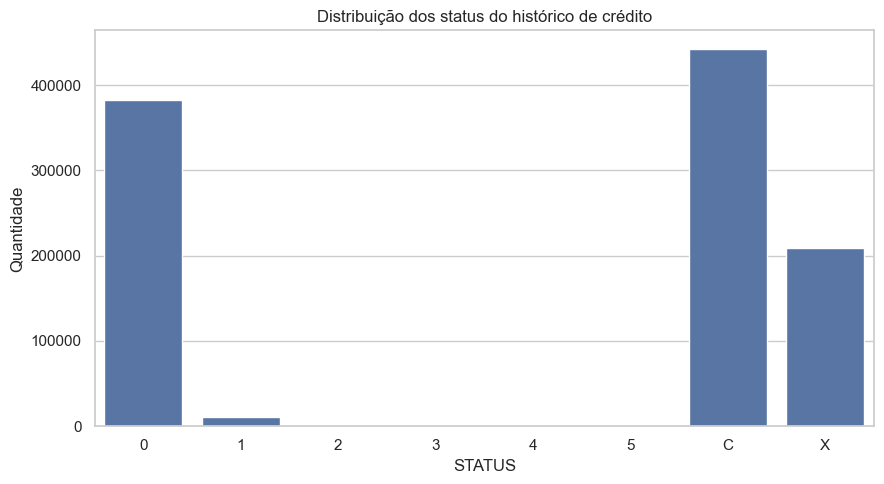

In [5]:
credit["STATUS_NUM"] = pd.to_numeric(credit["STATUS"], errors="coerce")

status_counts = (
    credit["STATUS"]
    .value_counts(dropna=False)
    .rename_axis("STATUS")
    .reset_index(name="quantidade")
)

display(status_counts)

plt.figure(figsize=(9, 5))
sns.countplot(data=credit, x="STATUS", order=sorted(credit["STATUS"].dropna().unique(), key=str))
plt.title("Distribuição dos status do histórico de crédito")
plt.xlabel("STATUS")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_status_credito.png", dpi=160, bbox_inches="tight")
plt.show()


Clientes com histórico: 45,985
TARGET=1: 667
Taxa TARGET=1: 1.45%


,TARGET,quantidade,percentual
0,0,35841,98.310338
1,1,616,1.689662


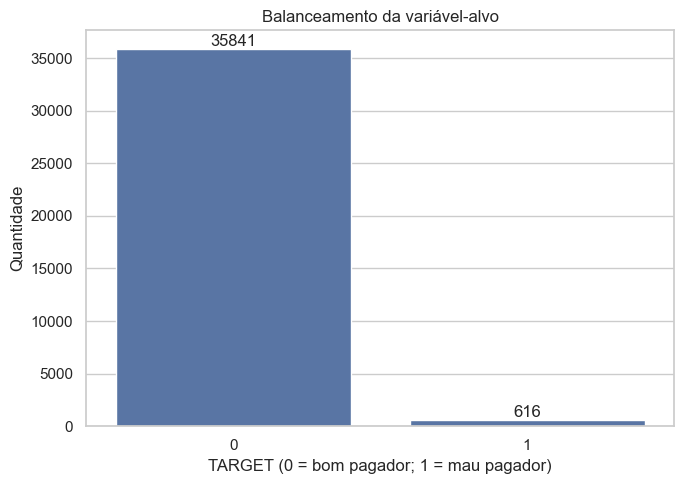

In [6]:
# Regra utilizada no projeto:
# STATUS 2, 3, 4 ou 5 em algum momento => mau pagador (TARGET=1).
worst_status = credit.groupby("ID")["STATUS_NUM"].max()
target_by_id = worst_status.isin([2, 3, 4, 5]).astype(int).rename("TARGET")

print("Clientes com histórico:", f"{target_by_id.size:,}")
print("TARGET=1:", f"{int(target_by_id.sum()):,}")
print("Taxa TARGET=1:", f"{target_by_id.mean() * 100:.2f}%")

df_eda = application.merge(
    target_by_id,
    left_on="ID",
    right_index=True,
    how="inner"
)

target_summary = (
    df_eda["TARGET"]
    .value_counts()
    .sort_index()
    .rename_axis("TARGET")
    .reset_index(name="quantidade")
)
target_summary["percentual"] = target_summary["quantidade"] / len(df_eda) * 100

display(target_summary)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_eda, x="TARGET")
plt.title("Balanceamento da variável-alvo")
plt.xlabel("TARGET (0 = bom pagador; 1 = mau pagador)")
plt.ylabel("Quantidade")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_balanceamento_target.png", dpi=160, bbox_inches="tight")
plt.show()


### Interpretação do balanceamento

A base final para modelagem depende da existência de histórico de crédito. A distribuição do `TARGET` deve ser analisada em termos de quantidade e percentual, pois a classe de maus pagadores é minoritária.

Esse desbalanceamento será considerado na escolha das métricas no notebook de modelagem/avaliação. A acurácia, isoladamente, não é suficiente para avaliar a capacidade de identificar `TARGET=1`.


## 3. Engenharia exploratória: idade, tempo de emprego e variáveis numéricas

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,36457.0,43.737717,11.500502,20.50,34.12,42.61,53.22,68.86
EMPLOYED_YEARS,30322.0,7.243014,6.454193,0.05,2.68,5.45,9.60,43.02
AMT_INCOME_TOTAL,36457.0,186685.736662,101789.226482,27000.00,121500.00,157500.00,225000.00,1575000.00
CNT_CHILDREN,36457.0,0.430315,0.742367,0.00,0.00,0.00,1.00,19.00
CNT_FAM_MEMBERS,36457.0,2.198453,0.911686,1.00,2.00,2.00,3.00,20.00
TARGET,36457.0,0.016897,0.128886,0.00,0.00,0.00,0.00,1.00


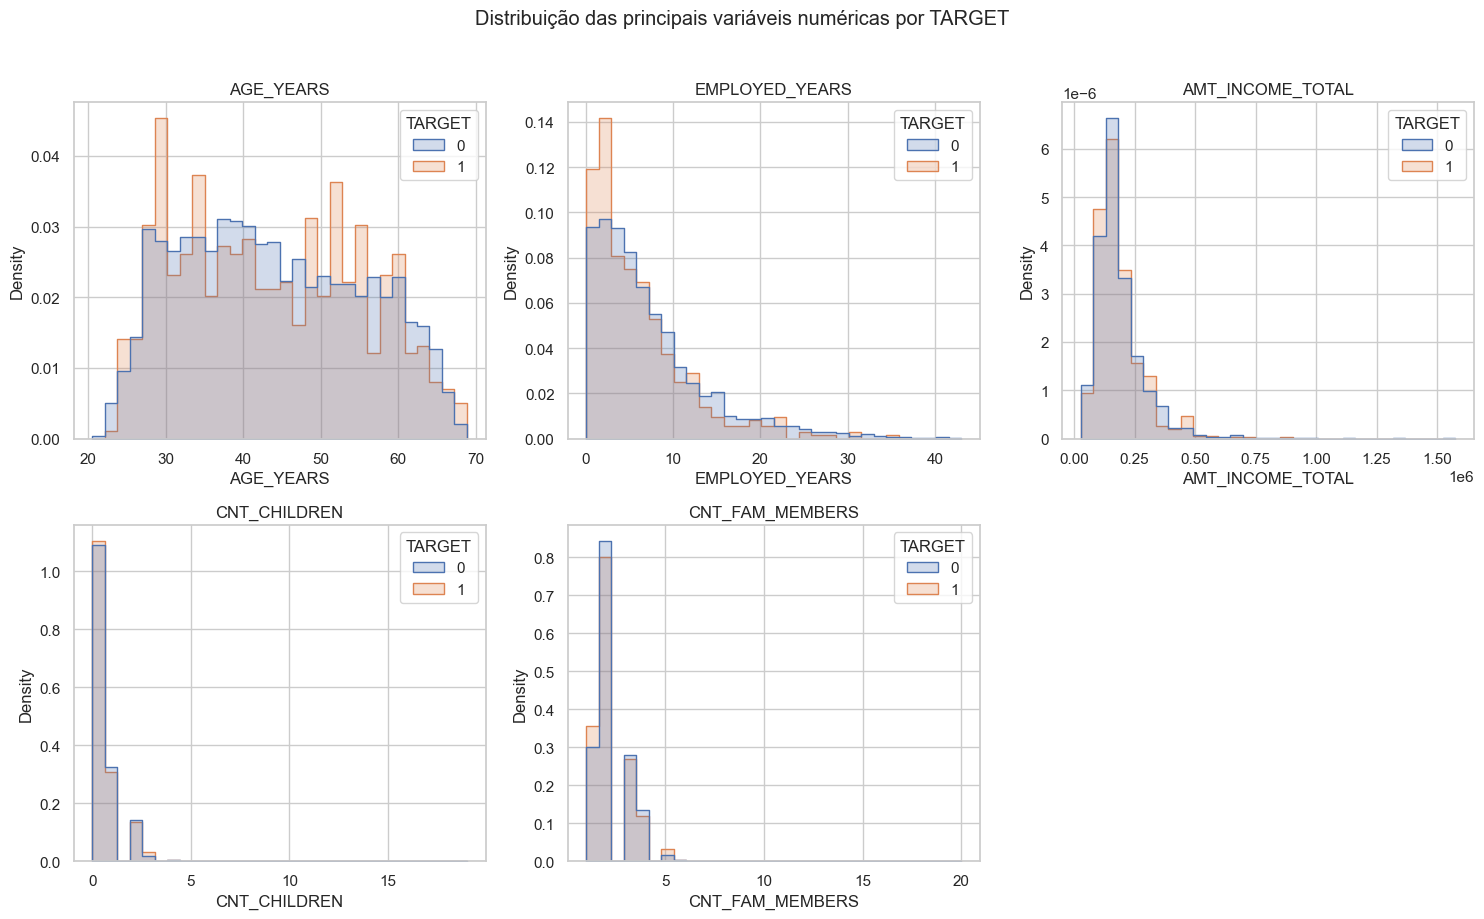

In [7]:
eda_num = df_eda.copy()

eda_num["AGE_YEARS"] = (-eda_num["DAYS_BIRTH"] / 365.25).round(2)
eda_num["EMPLOYED_YEARS"] = np.where(
    eda_num["DAYS_EMPLOYED"] < 0,
    -eda_num["DAYS_EMPLOYED"] / 365.25,
    np.nan
).round(2)

numeric_vars = [
    "AGE_YEARS",
    "EMPLOYED_YEARS",
    "AMT_INCOME_TOTAL",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
]

display(eda_num[numeric_vars + ["TARGET"]].describe().T)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, col in zip(axes, numeric_vars):
    sns.histplot(data=eda_num, x=col, hue="TARGET", bins=30, element="step",
                 stat="density", common_norm=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)

axes[-1].axis("off")
plt.suptitle("Distribuição das principais variáveis numéricas por TARGET", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_distribuicoes_numericas.png", dpi=160, bbox_inches="tight")
plt.show()


## 4. Outliers

,Q1,Q3,limite_inferior,limite_superior,outliers,percentual_outliers
AGE_YEARS,34.12,53.22,5.47,81.87,0.0,0.00
EMPLOYED_YEARS,2.68,9.60,-7.70,19.98,1741.0,5.74
AMT_INCOME_TOTAL,121500.00,225000.00,-33750.00,380250.00,1529.0,4.19
CNT_CHILDREN,0.00,1.00,-1.50,2.50,508.0,1.39
CNT_FAM_MEMBERS,2.00,3.00,0.50,4.50,480.0,1.32


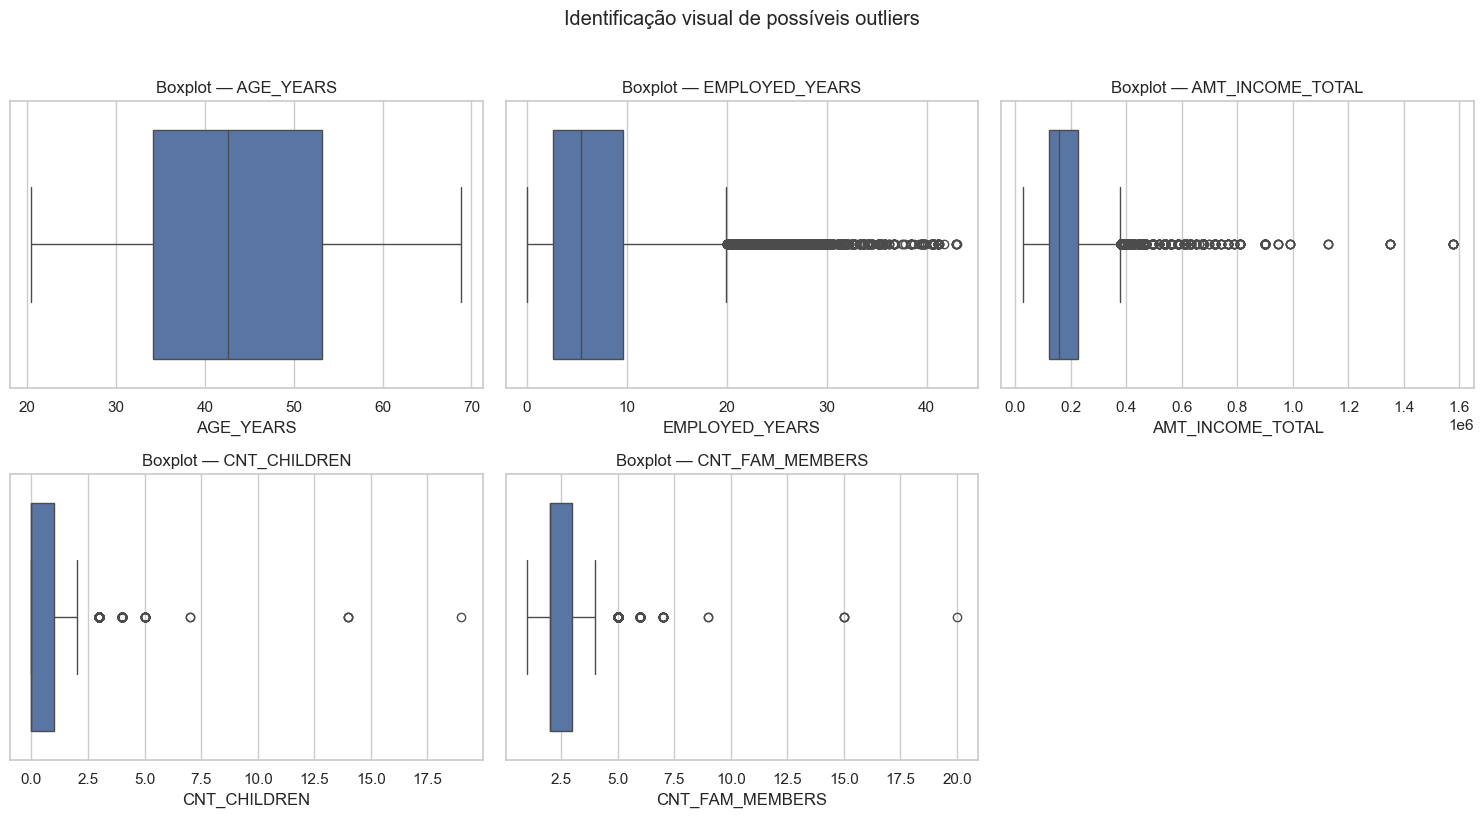

In [8]:
def iqr_summary(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)
    return {
        "Q1": q1,
        "Q3": q3,
        "limite_inferior": lower,
        "limite_superior": upper,
        "outliers": int(mask.sum()),
        "percentual_outliers": mask.mean() * 100,
    }

outlier_table = pd.DataFrame(
    {col: iqr_summary(eda_num[col]) for col in numeric_vars}
).T

display(outlier_table.round(2))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, numeric_vars):
    sns.boxplot(data=eda_num, x=col, ax=ax)
    ax.set_title(f"Boxplot — {col}")

axes[-1].axis("off")
plt.suptitle("Identificação visual de possíveis outliers", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_outliers_boxplots.png", dpi=160, bbox_inches="tight")
plt.show()


### Interpretação dos outliers

Os outliers são identificados pelo critério do intervalo interquartil (IQR). A tabela acima quantifica os casos e os boxplots permitem verificar visualmente a concentração e a dispersão.

A presença de valores extremos não implica automaticamente exclusão. A decisão de tratamento será tomada no pré-processamento/modelagem, considerando a natureza da variável e o impacto sobre os modelos.


## 5. Correlações

,AGE_YEARS,EMPLOYED_YEARS,AMT_INCOME_TOTAL,CNT_CHILDREN,CNT_FAM_MEMBERS,TARGET
AGE_YEARS,1.000,0.341,-0.068,-0.339,-0.304,-0.001
EMPLOYED_YEARS,0.341,1.000,0.020,-0.061,-0.045,-0.025
AMT_INCOME_TOTAL,-0.068,0.020,1.000,0.034,0.024,-0.001
CNT_CHILDREN,-0.339,-0.061,0.034,1.000,0.889,-0.000
CNT_FAM_MEMBERS,-0.304,-0.045,0.024,0.889,1.000,-0.006
TARGET,-0.001,-0.025,-0.001,-0.000,-0.006,1.000


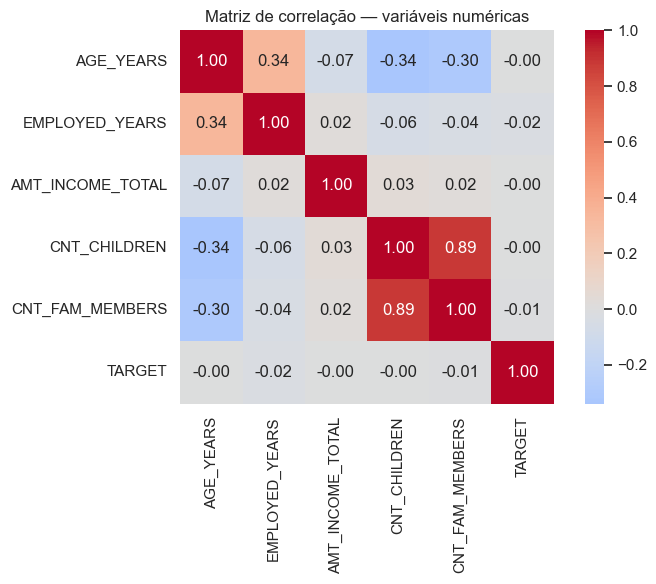

In [9]:
corr_cols = numeric_vars + ["TARGET"]
corr = eda_num[corr_cols].corr(numeric_only=True)

display(corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlação — variáveis numéricas")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_correlacoes.png", dpi=160, bbox_inches="tight")
plt.show()


### Interpretação das correlações

A matriz de correlação é utilizada como diagnóstico exploratório e não como prova de causalidade. Correlações próximas de zero indicam associação linear fraca; valores maiores devem ser avaliados em conjunto com a distribuição das variáveis e com a modelagem.

O `TARGET` é binário, portanto sua correlação com variáveis numéricas deve ser interpretada apenas como uma medida exploratória de associação linear.


## 6. Variáveis categóricas

In [10]:
categorical_vars = [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
]

for col in categorical_vars:
    if col not in eda_num.columns:
        continue

    table = (
        eda_num.groupby(col, dropna=False)["TARGET"]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
    )
    table["bad_rate_percent"] = table["mean"] * 100

    print(f"### {col}")
    display(table.head(15).round(4))


### CODE_GENDER


,count,mean,bad_rate_percent
CODE_GENDER,,,
F,24430,0.0155,1.5514
M,12027,0.0197,1.9706


### FLAG_OWN_CAR


,count,mean,bad_rate_percent
FLAG_OWN_CAR,,,
N,22614,0.0173,1.7334
Y,13843,0.0162,1.6181


### FLAG_OWN_REALTY


...

,count,mean,bad_rate_percent
NAME_EDUCATION_TYPE,,,
Secondary / secondary special,24777,0.0162,1.6225
Higher education,9864,0.0173,1.7336
Incomplete higher,1410,0.0234,2.3404
Lower secondary,374,0.0267,2.6738
Academic degree,32,0.0000,0.0000


### NAME_FAMILY_STATUS


,count,mean,bad_rate_percent
NAME_FAMILY_STATUS,,,
Married,25048,0.0157,1.5690
Single / not married,4829,0.0209,2.0915
Civil marriage,2945,0.0156,1.5620
Separated,2103,0.0147,1.4741
Widow,1532,0.0294,2.9373


### NAME_HOUSING_TYPE


,count,mean,bad_rate_percent
NAME_HOUSING_TYPE,,,
House / apartment,32548,0.0166,1.6591
With parents,1776,0.0146,1.4640
Municipal apartment,1128,0.0266,2.6596
Rented apartment,575,0.0139,1.3913
Office apartment,262,0.0344,3.4351
Co-op apartment,168,0.0179,1.7857


## 7. Perfis cadastrais repetidos

In [11]:
profile_cols = [c for c in application.columns if c != "ID"]

profile_sizes = application.groupby(profile_cols, dropna=False).size()

print("Perfis cadastrais distintos:", f"{profile_sizes.size:,}")
print("Perfis repetidos:", f"{int((profile_sizes > 1).sum()):,}")
print("Clientes pertencentes a perfis repetidos:", f"{int(profile_sizes[profile_sizes > 1].sum()):,}")

# Verifica conflitos de TARGET quando o mesmo perfil aparece em IDs diferentes.
profile_key = application[profile_cols].astype(str).agg("||".join, axis=1)
profile_map = pd.DataFrame({
    "PROFILE_KEY": profile_key,
    "TARGET": application["ID"].map(target_by_id)
}).dropna(subset=["TARGET"])

conflicting_profiles = (
    profile_map.groupby("PROFILE_KEY")["TARGET"]
    .nunique()
)

print("Perfis com TARGET conflitante:", f"{int((conflicting_profiles > 1).sum()):,}")


Perfis cadastrais distintos: 90,085
Perfis repetidos: 74,781
Clientes pertencentes a perfis repetidos: 423,253
Perfis com TARGET conflitante: 269


### Interpretação dos perfis repetidos

IDs diferentes podem representar exatamente o mesmo perfil cadastral. Esses registros não são eliminados automaticamente, porque representam clientes distintos.

A existência de perfis repetidos é importante para a etapa de modelagem: registros pertencentes ao mesmo perfil devem permanecer no mesmo conjunto de treino, validação ou teste. O `PROFILE_GROUP` será construído no `02_preprocessamento.ipynb` e utilizado para a divisão agrupada.


## 8. Resumo da EDA

A EDA deve responder, antes da modelagem:

1. **Qualidade:** quais colunas possuem valores ausentes e como as bases estão estruturadas?
2. **Alvo:** qual é o tamanho da base supervisionada e qual é a proporção de bons e maus pagadores?
3. **Distribuições:** como se comportam idade, tempo de emprego, renda e composição familiar?
4. **Outliers:** quais variáveis apresentam valores extremos pelo critério IQR?
5. **Correlações:** quais associações lineares aparecem entre as variáveis numéricas e o alvo?
6. **Perfis repetidos:** existem cadastros idênticos associados a IDs diferentes?
7. **Implicações para o pipeline:** o desbalanceamento e os perfis repetidos precisam ser considerados na modelagem.

### Próxima etapa

O `02_preprocessamento.ipynb` utiliza esses diagnósticos para integrar as fontes, construir a base de modelagem, tratar tipos/ausências, criar atributos derivados e preparar o agrupamento por perfil.
